In [1]:
import pandas as pd

# הנתיב לקובץ המקורי (לפי צילום המסך שלך)
input_path = r"C:\Users\ariel\Desktop\Seminar - Thesis\F-TM-CR\data\accepted_2007_to_2018Q4.csv"

# טעינת עמודת ה-zip_code בלבד לחיסכון בזיכרון
df_zip = pd.read_csv(input_path, usecols=['zip_code'], low_memory=False)

# יצירת ספירה של המיקודים והפיכה לטבלה (DataFrame)
# הפונקציה reset_index הופכת את התוצאה לטבלה מסודרת עם עמודות
unique_zips = df_zip['zip_code'].value_counts().reset_index()
unique_zips.columns = ['zip_code', 'count']

# שמירה לקובץ CSV (מומלץ למסדים גדולים)
output_path_csv = "unique_zip_codes.csv"
unique_zips.to_csv(output_path_csv, index=False)

# אם אתה מעדיף קובץ אקסל (שים לב שאקסל מוגבל למיליון שורות, אבל במיקודים ייחודיים אין בעיה)
# output_path_excel = "unique_zip_codes.xlsx"
# unique_zips.to_excel(output_path_excel, index=False)

print(f"הקובץ נוצר בהצלחה! סך הכל {len(unique_zips)} מיקודים ייחודיים נשמרו.")

הקובץ נוצר בהצלחה! סך הכל 956 מיקודים ייחודיים נשמרו.


In [9]:
import os
os.environ["CENSUS_API_KEY"] = "הדבק_כאן_את_המפתח"
API_KEY = os.getenv("CENSUS_API_KEY")
print("Loaded key:", API_KEY[:6], "OK")


Loaded key: הדבק_כ OK


In [17]:


import os
import time
import requests
import pandas as pd
from functools import reduce

# =========================================================
# 1) CONFIG
# =========================================================
API_KEY = "f805030986bb72960eb1f9a5c9da8138ff3ff8aa"  # <--- וודא שהמפתח כאן
YEARS = [2011, 2012, 2013, 2014]
OUT_DIR = r".\census_final_data"
os.makedirs(OUT_DIR, exist_ok=True)

# משתני מפתח למחקר אפליה
VARIABLES = {
    "B01003_001E": "total_pop",        # אוכלוסייה כללית
    "B19013_001E": "median_income",    # הכנסה חציונית
    "B03002_003E": "white_nh",         # לבנים (לא היספנים)
    "B03002_004E": "black_nh",         # שחורים (לא היספנים)
    "B03002_012E": "hispanic",         # היספנים
    "B17001_002E": "poverty_count",    # מספר אנשים מתחת לקו העוני
    "B11001_001E": "total_households"  # סך משקי בית (לשקלול)
}

def fetch_variable_clean(year, var_code):
    base_url = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": var_code, # אנחנו מושכים רק את הקוד עצמו בלי NAME כדי למנוע כפילויות
        "for": "zip code tabulation area:*",
        "key": API_KEY
    }
    
    try:
        r = requests.get(base_url, params=params, timeout=30)
        if r.status_code == 200:
            data = r.json()
            df = pd.DataFrame(data[1:], columns=data[0])
            # שינוי שם העמודה לשם "ידידותי" ושמירת ה-ZCTA
            df = df.rename(columns={
                "zip code tabulation area": "zcta",
                var_code: VARIABLES[var_code]
            })
            # שמירה רק על עמודת המפתח והנתון
            return df[["zcta", VARIABLES[var_code]]]
        return None
    except:
        return None

# =========================================================
# 2) EXECUTION
# =========================================================
all_years_final = []

for year in YEARS:
    print(f"\n--- Processing Year {year} ---")
    year_data_frames = []
    
    for var_code, var_name in VARIABLES.items():
        print(f"  Fetching {var_name}...")
        df = fetch_variable_clean(year, var_code)
        if df is not None:
            year_data_frames.append(df)
        time.sleep(0.5)

    if year_data_frames:
        # איחוד כל המשתנים לפי ZCTA
        # משתמשים ב-outer join כדי לא לאבד נתונים אם משתנה חסר ב-ZIP מסוים
        merged_year = reduce(lambda left, right: pd.merge(left, right, on="zcta", how="outer"), year_data_frames)
        
        # ניקוי ערכים שליליים והמרה למספרים
        for col in merged_year.columns:
            if col != "zcta":
                merged_year[col] = pd.to_numeric(merged_year[col], errors='coerce').apply(lambda x: x if (x and x >= 0) else None)
        
        # אגרגציה ל-ZIP3
        merged_year["zip3"] = merged_year["zcta"].astype(str).str.zfill(5).str[:3]
        
        # יצירת טבלת ה-ZIP3 הסופית לשנה זו
        zip3_final = merged_year.groupby("zip3").agg({
            "total_pop": "sum",
            "white_nh": "sum",
            "black_nh": "sum",
            "hispanic": "sum",
            "poverty_count": "sum",
            "total_households": "sum"
        }).reset_index()
        
        # חישוב הכנסה חציונית משוקללת (מקורב)
        income_agg = merged_year.dropna(subset=["median_income", "total_households"])
        if not income_agg.empty:
            weighted_inc = income_agg.groupby("zip3").apply(
                lambda x: (x["median_income"] * x["total_households"]).sum() / x["total_households"].sum()
            ).reset_index(name="median_income_approx")
            zip3_final = zip3_final.merge(weighted_inc, on="zip3", how="left")
        
        # הוספת שנה ומדדי יחס (Shares)
        zip3_final["year"] = year
        zip3_final["share_black"] = zip3_final["black_nh"] / zip3_final["total_pop"]
        zip3_final["share_hispanic"] = zip3_final["hispanic"] / zip3_final["total_pop"]
        zip3_final["poverty_rate"] = zip3_final["poverty_count"] / zip3_final["total_pop"]
        
        # שמירת קובץ ביניים
        zip3_final.to_csv(os.path.join(OUT_DIR, f"results_{year}.csv"), index=False)
        all_years_final.append(zip3_final)
        print(f"  [SUCCESS] Year {year} complete.")

# איחוד סופי לכל השנים
if all_years_final:
    pd.concat(all_years_final).to_csv(os.path.join(OUT_DIR, "final_discrimination_panel.csv"), index=False)
    print(f"\nDONE! All data saved in {OUT_DIR}")


--- Processing Year 2011 ---
  Fetching total_pop...
  Fetching median_income...
  Fetching white_nh...
  Fetching black_nh...
  Fetching hispanic...
  Fetching poverty_count...
  Fetching total_households...


C:\Users\ariel\AppData\Local\Temp\ipykernel_33096\1032185852.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_inc = income_agg.groupby("zip3").apply(


  [SUCCESS] Year 2011 complete.

--- Processing Year 2012 ---
  Fetching total_pop...
  Fetching median_income...
  Fetching white_nh...
  Fetching black_nh...
  Fetching hispanic...
  Fetching poverty_count...
  Fetching total_households...


C:\Users\ariel\AppData\Local\Temp\ipykernel_33096\1032185852.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_inc = income_agg.groupby("zip3").apply(


  [SUCCESS] Year 2012 complete.

--- Processing Year 2013 ---
  Fetching total_pop...
  Fetching median_income...
  Fetching white_nh...
  Fetching black_nh...
  Fetching hispanic...
  Fetching poverty_count...
  Fetching total_households...


C:\Users\ariel\AppData\Local\Temp\ipykernel_33096\1032185852.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_inc = income_agg.groupby("zip3").apply(


  [SUCCESS] Year 2013 complete.

--- Processing Year 2014 ---
  Fetching total_pop...
  Fetching median_income...
  Fetching white_nh...
  Fetching black_nh...
  Fetching hispanic...
  Fetching poverty_count...
  Fetching total_households...
  [SUCCESS] Year 2014 complete.

DONE! All data saved in .\census_final_data


C:\Users\ariel\AppData\Local\Temp\ipykernel_33096\1032185852.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_inc = income_agg.groupby("zip3").apply(


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. הגדרת הנתיב - אם הקובץ באותה תיקייה של הקוד, השתמש רק בשם הקובץ
# אם הוא בתוך התיקייה שנוצרה קודם, השתמש בנתיב היחסי:
file_path = 'final_discrimination_panel.csv' 

if not os.path.exists(file_path):
    file_path = r'.\census_final_data\final_discrimination_panel.csv'

# 2. טעינה ל-DataFrame
try:
    df = pd.read_csv(file_path)
    print("✅ הטעינה הושלמה בהצלחה!")
    print(f"שורות: {df.shape[0]}, עמודות: {df.shape[1]}")
    
    # המרה של עמודת zip3 למחרוזת (כדי שלא יתייחס אליה כאל מספר בגרפים)
    df['zip3'] = df['zip3'].astype(str).str.zfill(3)
    
except FileNotFoundError:
    print("❌ שגיאה: הקובץ לא נמצא. וודא ששם הקובץ והנתיב נכונים.")

✅ הטעינה הושלמה בהצלחה!
שורות: 3576, עמודות: 12


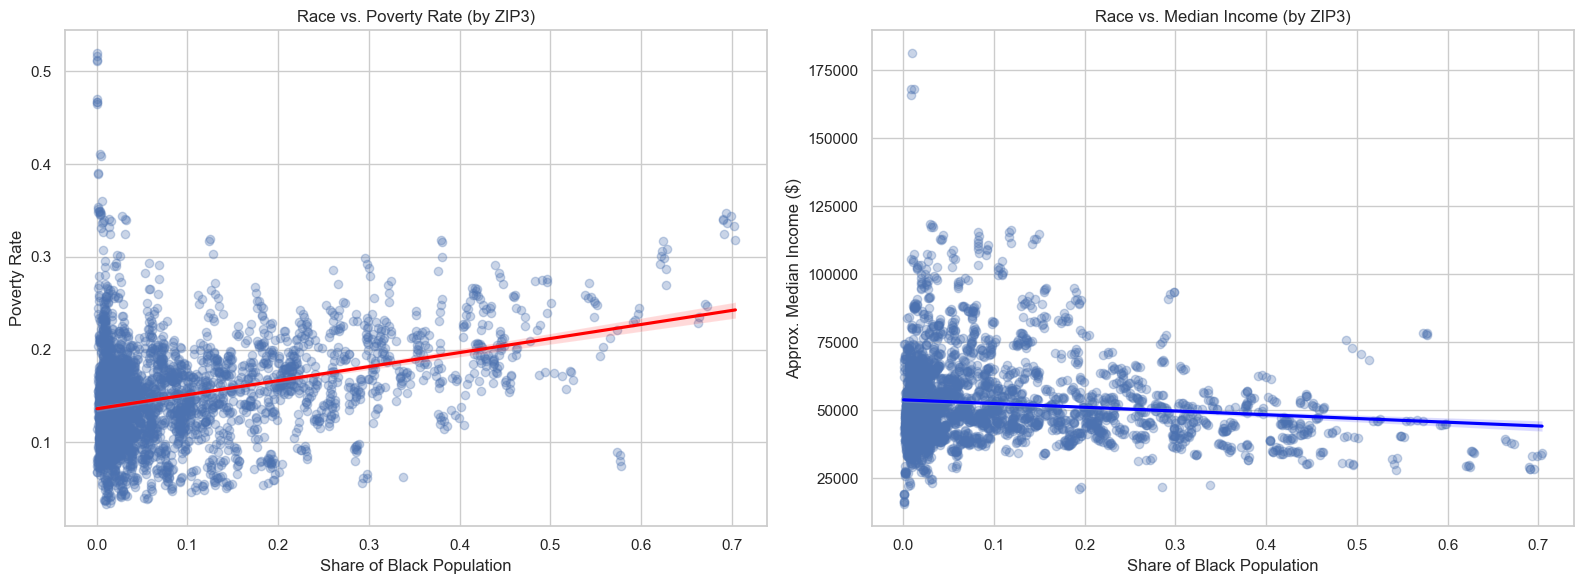


--- מטריצת מתאמים (Correlation Matrix) ---
                      share_black  poverty_rate  median_income_approx
share_black              1.000000      0.339033             -0.111850
poverty_rate             0.339033      1.000000             -0.724741
median_income_approx    -0.111850     -0.724741              1.000000


In [26]:
# הגדרת סגנון ויזואלי
sns.set_theme(style="whitegrid")

# יצירת איור עם שני גרפים להשוואה
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# גרף 1: קשר בין אחוז אוכלוסייה שחורה לעוני
sns.regplot(data=df, x='share_black', y='poverty_rate', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=ax1)
ax1.set_title('Race vs. Poverty Rate (by ZIP3)')
ax1.set_xlabel('Share of Black Population')
ax1.set_ylabel('Poverty Rate')

# גרף 2: קשר בין אחוז אוכלוסייה שחורה להכנסה חציונית
sns.regplot(data=df, x='share_black', y='median_income_approx', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'blue'}, ax=ax2)
ax2.set_title('Race vs. Median Income (by ZIP3)')
ax2.set_xlabel('Share of Black Population')
ax2.set_ylabel('Approx. Median Income ($)')

plt.tight_layout()
plt.show()

# הצגת מטריצת מתאמים מספרית
correlation = df[['share_black', 'poverty_rate', 'median_income_approx']].corr()
print("\n--- מטריצת מתאמים (Correlation Matrix) ---")
print(correlation)